# Week 1 — Exploring the PicoCal Run5-like matched-cluster dataset

Data: 100 `matched_*.root` files (tree `clusters_matched`). One entry is one reconstructed
5×5-module cluster window matched to one true photon. Physics background and the branch glossary
are in [`docs/physics-primer.md`](../docs/physics-primer.md).

What I want from this notebook:

1. Check the dataset against its specification (schema, units, padding conventions).
2. Understand the inputs a transformer would see: token counts, feature ranges, timing quality.
3. Look at the physics that motivates the proposal: longitudinal energy sharing and timing.
4. Set up a classical baseline (calibrated sum of cells) to compare models against later.
5. Collect open questions for the mentors (section 11).

## Summary of results

| Topic | Result | Section |
|---|---|---|
| Dataset | 199,538 matched photon-clusters, 100 files, 47 branches | 1 |
| Target units | `sig_flux_eTot` is in GeV (the spec sheet says MeV) | 2a |
| Reco energy scale | uncalibrated; gain ≈ 967 raw units / GeV | 8c |
| Cluster sharing | 67% of photons share their cluster with a sibling photon, so energy regression is also an overlap problem | 8b |
| Token budget | informative cells per cluster: p50 = 71, p99 ≈ 200, max = 528 | 5 |
| Baseline resolution | isolated photons: σ/E = (11.3 ± 1.1)%/√E ⊕ (2.94 ± 0.14)%, fitted for E > 10 GeV | 8c |
| Depth information | correlation between response residual and front fraction: ρ ≈ 0 below 50 GeV, +0.25 ± 0.05 at 170 GeV; a linear depth correction gains ~8% there | 8d |
| Timing quality | cell-time resolution improves with cell energy: 0.9 ns → 0.36 ns → ~12 ps for the hottest cells (SPIDER design is 15 ps) | 4b |
| Position | stored `x_cluster` is quantized and 48 mm from truth; a log-weighted centroid gets 8.6 mm | 9 |

In short: the calorimeter is linear for isolated photons. The room for improvement is
contamination and overlap rejection at low energy, depth and timing corrections at high energy,
and position reconstruction everywhere.

In [1]:
from pathlib import Path

import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import uproot

import picocal
from picocal.data import (
    load_clusters, valid_cell_mask, clean_cell_times, cluster_to_tokens,
    truth_dataframe, TREE_NAME, BRANCHES_TRUTH, BRANCHES_CLUSTER, BRANCHES_CELL,
)

plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": True, "font.size": 11})
rng = np.random.default_rng(42)

# Silence two benign warnings that would otherwise clutter the outputs:
# numpy's masked-array partition note (raised by hist2d with cmin) and
# scipy's covariance note on the deliberately simple resolution fit.
import warnings
from scipy.optimize import OptimizeWarning
warnings.filterwarnings("ignore", category=OptimizeWarning)
warnings.filterwarnings("ignore", message=".*will ignore the 'mask'.*")

REPO = Path(picocal.__file__).resolve().parents[2]
DATA_DIR = REPO / "data" / "full"
FILES = sorted(DATA_DIR.glob("matched_*.root"))
print(f"Found {len(FILES)} ROOT files in {DATA_DIR.relative_to(REPO)}/")

# Cell-level work uses a 10-file sample; scalar statistics use all files.
N_DEEP = 10

Found 100 ROOT files in data/full/


## 1. File and schema inventory

First check: does the data on disk match the dataset specification
(`gsoc26_instruction.pdf`), and how much of it is there?

In [2]:
counts = []
for f in FILES:
    with uproot.open(f) as fh:
        counts.append(fh[TREE_NAME].num_entries)
counts = np.array(counts)
print(f"Total matched clusters: {counts.sum():,} across {len(FILES)} files")
print(f"Entries/file: min {counts.min()}  median {np.median(counts):.0f}  max {counts.max()}")

with uproot.open(FILES[0]) as fh:
    tree = fh[TREE_NAME]
    schema = {n: b.typename for n, b in tree.items()}
print(f"\n{len(schema)} branches:")
for n, t in schema.items():
    print(f"  {n:28s} {t}")

Total matched clusters: 199,538 across 100 files
Entries/file: min 1647  median 2021  max 2176

47 branches:
  sig_flux_entry_x             double
  sig_flux_entry_y             double
  sig_flux_entry_z             double
  sig_flux_px                  double
  sig_flux_py                  double
  sig_flux_pz                  double
  sig_flux_prod_vertex_x       double
  sig_flux_prod_vertex_y       double
  sig_flux_prod_vertex_z       double
  sig_flux_timing              double
  sig_flux_eTot                double
  sig_flux_pdgID               int32_t
  sig_dr_matched               double
  sig_dxdz_flux                double
  sig_dydz_flux                double
  seed_icell_x                 int64_t
  seed_icell_y                 int64_t
  nseed_cell_x                 int32_t
  seed_cell_x                  double[]
  nseed_cell_y                 int32_t
  seed_cell_y                  double[]
  nimodx                       int32_t
  imodx                        int64_t[]
  nj

Differences with respect to the spec sheet:

| Observation | Consequence |
|---|---|
| `cell_pitch`, `cell_modType`, `cell_rel_x/y/dr` **absent** in this production | Granularity/region features must be *derived* (e.g. from local cell spacing) or requested from the mentors |
| `sig_flux_timing` **present** but undocumented | A truth-level photon time — useful timing reference (verified in §4) |
| `seed_icell_x/y`, `seed_cell_x/y` present but undocumented | Reconstructed seed location — useful for §9 |
| Every cell array has an `n*` length branch | Padding handling is testable (§2) |

## 2. Data-quality checks

Before any analysis I check units, label purity, array-length conventions, timing values and
event multiplicity. Several of these turned out different from the documentation.

In [3]:
deep = load_clusters(
    FILES[:N_DEEP],
    branches=BRANCHES_TRUTH + BRANCHES_CLUSTER + BRANCHES_CELL + ["nenergy"],
)
print(f"Cell-level sample: {len(deep):,} clusters from {N_DEEP} files")

# --- 2a. Units of the regression target ------------------------------------
e_true_raw = ak.to_numpy(deep.sig_flux_eTot)
e_reco = ak.to_numpy(deep.total_energy)
print("\n[2a] sig_flux_eTot:  min %.2f  median %.2f  max %.2f" %
      (e_true_raw.min(), np.median(e_true_raw), e_true_raw.max()))
print("     total_energy:   min %.0f  median %.0f  max %.0f" %
      (e_reco.min(), np.median(e_reco), e_reco.max()))
print("     median(total_energy / sig_flux_eTot) = %.0f" % np.median(e_reco / e_true_raw))

Cell-level sample: 18,927 clusters from 10 files

[2a] sig_flux_eTot:  min 1.00  median 4.09  max 235.06
     total_energy:   min 217  median 35165  max 226396
     median(total_energy / sig_flux_eTot) = 6239


Two things to note here. First, `sig_flux_eTot` spans 1–235 with a median around 4, so the unit
is GeV, not MeV as the spec sheet says. The example notebook from the mentors multiplies it by
1000, which agrees with the data. Second, even after converting units, the ratio
`total_energy / E_true` is far from 1: the reconstructed energy is uncalibrated raw output.
Any energy-response study has to fit a calibration first (section 8).

In [4]:
# --- 2b. Label purity & basic integrity -------------------------------------
pdg = ak.to_numpy(deep.sig_flux_pdgID)
print("[2b] pdgID composition:", dict(zip(*np.unique(pdg, return_counts=True))), "(22 = photon)")

for b in ["sig_flux_eTot", "total_energy", "x_cluster", "y_cluster"]:
    v = ak.to_numpy(deep[b])
    assert np.isfinite(v).all(), b
print("     no NaN/inf in cluster-level scalars")
print("     negative cell energies:", int(ak.sum(deep.energy < 0)))

# --- 2c. Are the n* branches a padding mask? --------------------------------
raw_len = ak.num(deep.energy, axis=1)
n_branch = deep["nenergy"] if "nenergy" in deep.fields else None
agree = bool(ak.all(raw_len == n_branch)) if n_branch is not None else None
print(f"[2c] n* branch == raw array length for every cluster: {agree}")
nonzero = ak.sum(deep.energy != 0, axis=1)
print("     cells per window:  median %d   | with energy>0: median %d (%.0f%%)" %
      (np.median(ak.to_numpy(raw_len)), np.median(ak.to_numpy(nonzero)),
       100 * float(ak.sum(nonzero)) / float(ak.sum(raw_len))))

[2b] pdgID composition: {np.int32(22): np.int64(18927)} (22 = photon)
     no NaN/inf in cluster-level scalars
     negative cell energies: 0
[2c] n* branch == raw array length for every cluster: True
     cells per window:  median 144   | with energy>0: median 71 (42%)


The arrays are jagged, and the `n*` branches always equal the raw array length, so the
zero-padded fixed-size arrays described in the spec do not exist in this production. About half
of the cells in each window have `energy == 0`: real geometry positions with no deposit. I drop
them when building tokens, since a zero-energy cell carries no information and its other fields
are unreliable (see the timing check below).

In [5]:
# --- 2d. Timing sanity -------------------------------------------------------
tf = deep.cell_times_front
print("[2d] cell_times_front raw range: [%.3g, %.3g] ns" % (ak.min(tf), ak.max(tf)))
mask = valid_cell_mask(deep)
garbage_in_live = ak.sum((abs(tf) > 1e4) & mask)
garbage_in_silent = ak.sum((abs(tf) > 1e4) & ~mask)
print(f"     |t| > 1e4 ns entries: {int(garbage_in_live)} in cells WITH energy, "
      f"{int(garbage_in_silent)} in silent cells")
tf_clean = clean_cell_times(tf, mask)
flat = ak.to_numpy(ak.flatten(tf_clean))
flat = flat[np.isfinite(flat)]
print("     cleaned times: median %.2f ns, [p1, p99] = [%.2f, %.2f] ns" %
      (np.median(flat), *np.percentile(flat, [1, 99])))

[2d] cell_times_front raw range: [-6.81e+37, 204] ns
     |t| > 1e4 ns entries: 566713 in cells WITH energy, 1945560 in silent cells
     cleaned times: median 85.58 ns, [p1, p99] = [84.89, 139.56] ns


The timing branches contain uninitialised values (down to about −7·10³⁷ ns) in cells without a
deposit, and in roughly 20% of cells with one. After requiring `energy > 0` and |t| < 10⁴ ns the
distribution is narrow and centred near 86 ns, about twice the photon time of flight to the ECAL
face (42 ns, section 4). The extra delay probably includes shower development, light propagation
and the readout path; the exact time reference is on the mentor-question list. The cleaning rule
is implemented in `clean_cell_times` in the loader, with unit tests.

In [6]:
# --- 2e. Event multiplicity ---------------------------------------------------
import collections
ev = ak.to_numpy(deep.event)
mult = collections.Counter(collections.Counter(ev).values())
print("[2e] clusters per event index:", dict(sorted(mult.items())))

[2e] clusters per event index: {1: 4, 2: 8, 3: 21, 4: 10, 5: 9, 6: 12, 7: 15, 8: 18, 9: 20, 10: 18, 11: 38, 12: 29, 13: 35, 14: 47, 15: 46, 16: 46, 17: 56, 18: 50, 19: 47, 20: 59, 21: 42, 22: 42, 23: 46, 24: 36, 25: 34, 26: 27, 27: 23, 28: 29, 29: 24, 30: 22, 31: 9, 32: 9, 33: 10, 34: 8, 35: 8, 36: 8, 37: 11, 38: 2, 39: 3, 41: 3, 42: 3, 45: 2, 50: 1, 53: 1}


One event can contain up to about 13 matched photons, sometimes within a millimetre of each
other. The spec says "one event = one matched cluster", but the same `event` index appears with
different true photons. This means train/validation/test splits have to be done by event index,
not by entry, and photons from the same event can overlap in the calorimeter. Section 8b looks
at the consequences.

## 3. Truth distributions

What do the labels look like? The energy spectrum, impact-point coverage and incidence angles
define the domain a model has to cover. This part uses cluster-level scalars from all 100 files;
the cell-level work stays on the 10-file sample.

Full dataset: 199,538 matched clusters


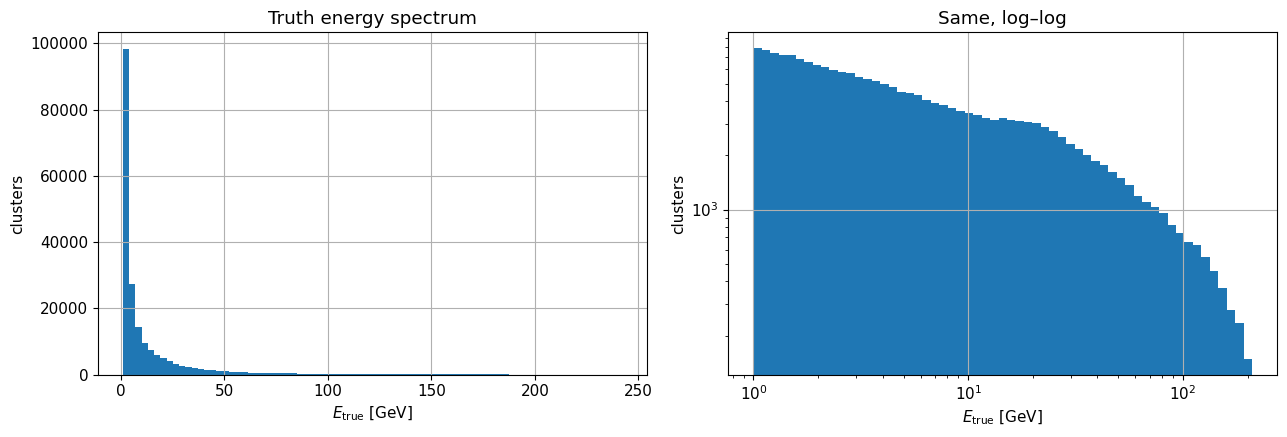

E_true percentiles [GeV]: {1: np.float64(1.0), 5: np.float64(1.1), 50: np.float64(4.1), 95: np.float64(56.3), 99: np.float64(124.0)}


In [7]:
dfs = []
for i, f in enumerate(FILES):
    part = truth_dataframe(load_clusters(f, branches=BRANCHES_TRUTH + BRANCHES_CLUSTER))
    part["file"] = i
    dfs.append(part)
df = pd.concat(dfs, ignore_index=True)
df["e_true_gev"] = df["sig_flux_eTot"]
print(f"Full dataset: {len(df):,} matched clusters")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df.e_true_gev, bins=80)
axes[0].set(xlabel=r"$E_{\rm true}$ [GeV]", ylabel="clusters", title="Truth energy spectrum")
axes[1].hist(df.e_true_gev, bins=np.geomspace(1, 210, 60))
axes[1].set(xscale="log", yscale="log", xlabel=r"$E_{\rm true}$ [GeV]", ylabel="clusters",
            title="Same, log–log")
plt.tight_layout(); plt.show()
print("E_true percentiles [GeV]:",
      {p: round(v, 1) for p, v in zip([1,5,50,95,99], np.percentile(df.e_true_gev, [1,5,50,95,99]))})

The spectrum falls steeply, as expected for collision photons. Most examples are below ~10 GeV,
while the constant term of the resolution is probed at high energy where statistics are thin.
A log-energy target or energy-balanced sampling will probably be needed; noted for Week 2.

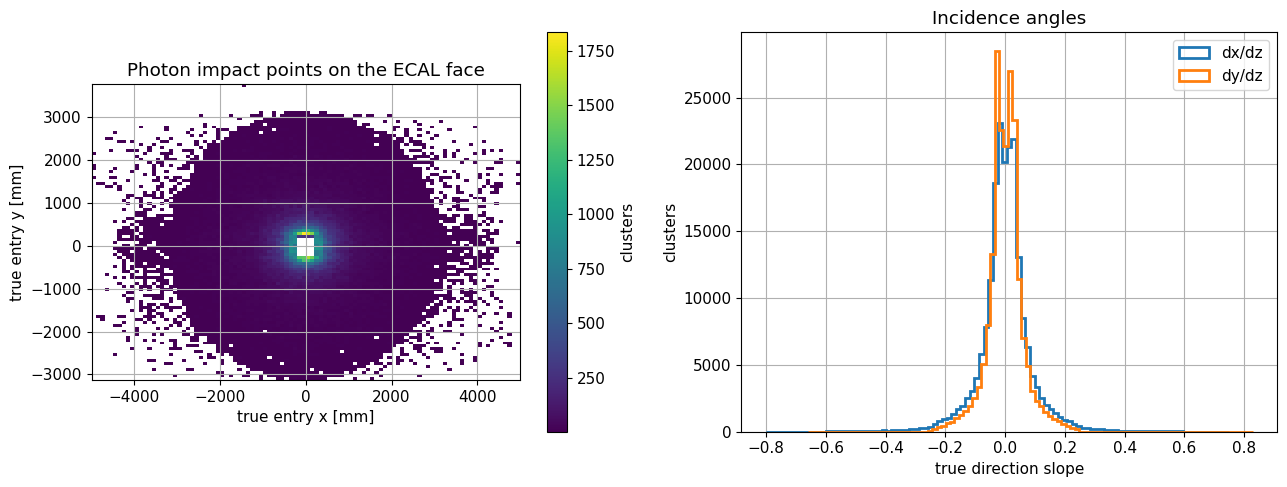

radial impact distance percentiles [mm]: {1: 262, 50: 656, 99: 3118}


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
h = axes[0].hist2d(df.sig_flux_entry_x, df.sig_flux_entry_y, bins=100, cmin=1)
plt.colorbar(h[3], ax=axes[0], label="clusters")
axes[0].set(xlabel="true entry x [mm]", ylabel="true entry y [mm]",
            title="Photon impact points on the ECAL face", aspect="equal")
axes[1].hist(df.sig_dxdz_flux, bins=100, histtype="step", lw=2, label="dx/dz")
axes[1].hist(df.sig_dydz_flux, bins=100, histtype="step", lw=2, label="dy/dz")
axes[1].set(xlabel="true direction slope", ylabel="clusters", title="Incidence angles")
axes[1].legend()
plt.tight_layout(); plt.show()
r = np.hypot(df.sig_flux_entry_x, df.sig_flux_entry_y)
print("radial impact distance percentiles [mm]:",
      {p: round(v) for p, v in zip([1,50,99], np.percentile(r, [1,50,99]))})

Impact points cover the full ECAL face, concentrated towards the beam pipe. The slope
distributions show photons arrive at angles up to ~0.3 rad, so the shower axis is tilted and the
lateral shape is smeared. A model that sees the full lateral pattern can in principle correct
for this; angle-binned evaluation goes on the later to-do list.

## 4. Cross-checking the undocumented `sig_flux_timing`

This branch is not in the documentation. If it is the photon's arrival time at the ECAL, it
should equal $d/c$ with $d = \sqrt{x^2+y^2+z^2}$ the distance from the origin to the entry point.

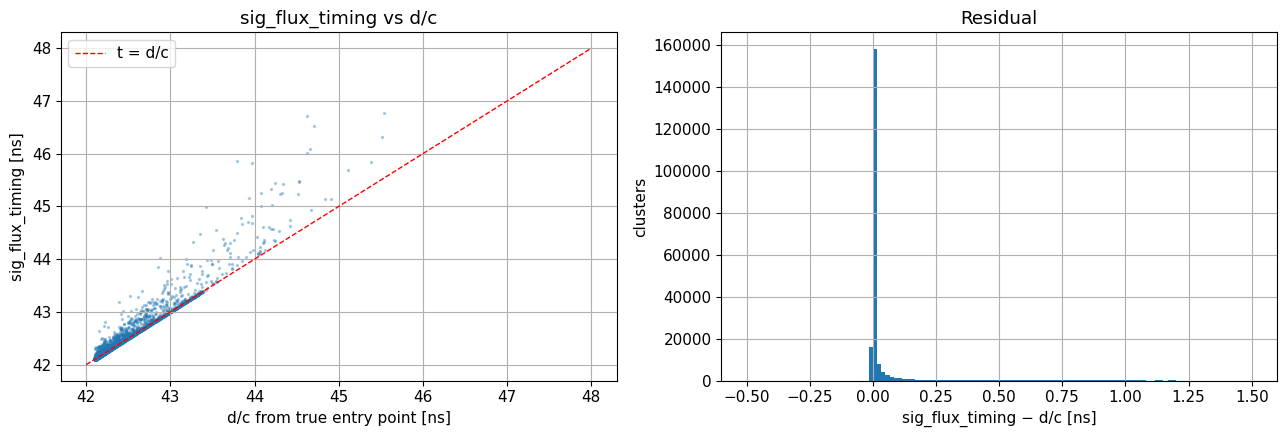

median residual: 0.0000 ns,  p95: 0.0774 ns


In [9]:
d = np.sqrt(df.sig_flux_entry_x**2 + df.sig_flux_entry_y**2 + df.sig_flux_entry_z**2)
c_mm_ns = 299.792458
tof = d / c_mm_ns
resid = df.sig_flux_timing - tof

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(tof[::20], df.sig_flux_timing[::20], s=2, alpha=0.3)
axes[0].plot([42, 48], [42, 48], "r--", lw=1, label="t = d/c")
axes[0].set(xlabel="d/c from true entry point [ns]", ylabel="sig_flux_timing [ns]",
            title="sig_flux_timing vs d/c")
axes[0].legend()
axes[1].hist(resid, bins=120, range=(-0.5, 1.5))
axes[1].set(xlabel="sig_flux_timing − d/c [ns]", ylabel="clusters", title="Residual")
plt.tight_layout(); plt.show()
print("median residual: %.4f ns,  p95: %.4f ns" % (np.median(resid), np.percentile(resid, 95)))

It matches: `sig_flux_timing` sits on t = d/c with a small positive tail from photons produced
at displaced vertices. So this is the truth arrival time at the ECAL, which gives a reference
for interpreting the measured cell times in the next section.

### 4b. Timing quality

Are the `cell_times_*` branches pure simulation truth, or smeared like a real detector? With the
truth arrival time from section 4 I can look at the per-cell residual `t_front − t_truth` and at
how its width scales with cell energy. Real photodetector timing improves with signal amplitude,
roughly like 1/√(signal), while pure truth would show no such dependence.

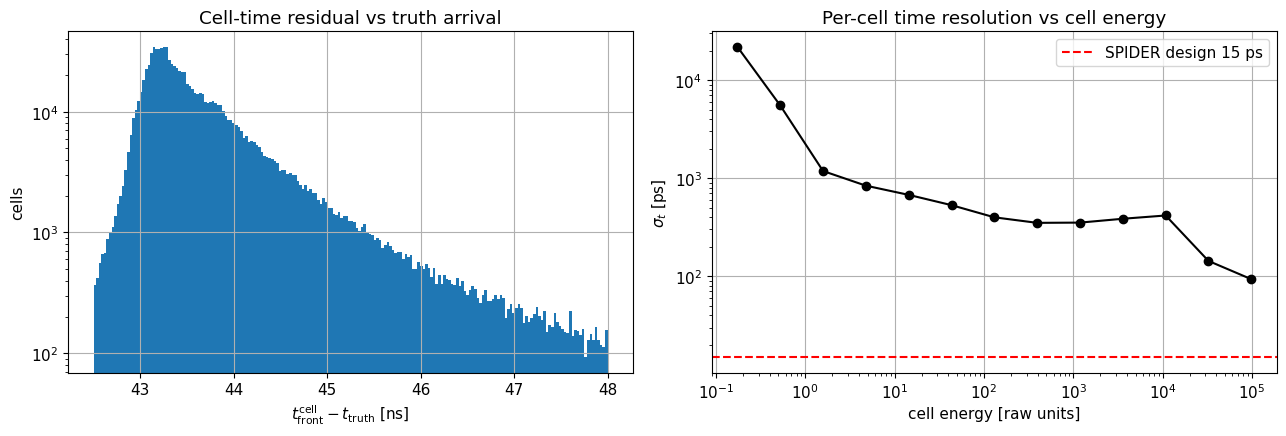

t_front - t_truth: median offset 43.45 ns (constant light-collection/readout delay)
  sigma_t =    898.5 ps   for cell E in [1, 10)  (n=217426)
  sigma_t =    571.7 ps   for cell E in [10, 100)  (n=454004)
  sigma_t =    359.8 ps   for cell E in [100, 100000)  (n=291372)
  sigma_t =     12.4 ps   for cell E in [100000, 1e+09)  (n=540)
t_back - t_front: median +0.182 ns, robust sigma 0.557 ns


In [10]:
mask = valid_cell_mask(deep)
tfc = clean_cell_times(deep.cell_times_front, mask)
tbc = clean_cell_times(deep.cell_times_back, mask)
res = tfc - deep.sig_flux_timing          # broadcasts the per-cluster truth time over cells
rf = ak.to_numpy(ak.flatten(res))
ec = ak.to_numpy(ak.flatten(deep.energy))
fin = np.isfinite(rf)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(rf[fin], bins=200, range=(42.5, 48))
axes[0].set(xlabel=r"$t_{\rm front}^{\rm cell} - t_{\rm truth}$ [ns]", ylabel="cells",
            title="Cell-time residual vs truth arrival", yscale="log")

bins = np.geomspace(max(ec[fin & (ec > 0)].min(), 1e-1), ec[fin].max(), 14)
ctr, wid = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = fin & (ec >= lo) & (ec < hi)
    if m.sum() > 300:
        q16, q84 = np.percentile(rf[m], [15.865, 84.135])
        ctr.append(np.sqrt(lo * hi)); wid.append(0.5 * (q84 - q16))
axes[1].plot(ctr, 1e3 * np.array(wid), "ko-")
axes[1].axhline(15e-3 * 1e3, color="r", ls="--", label="SPIDER design 15 ps")
axes[1].set(xscale="log", yscale="log", xlabel="cell energy [raw units]",
            ylabel=r"$\sigma_t$ [ps]", title="Per-cell time resolution vs cell energy")
axes[1].legend()
plt.tight_layout(); plt.show()

dt = ak.to_numpy(ak.flatten(tbc - tfc)); dt = dt[np.isfinite(dt)]
q = np.percentile(dt, [15.865, 50, 84.135])
print("t_front - t_truth: median offset %.2f ns (constant light-collection/readout delay)"
      % np.median(rf[fin]))
for lo, hi in [(1, 10), (10, 100), (100, 1e5), (1e5, 1e9)]:
    m = fin & (ec >= lo) & (ec < hi)
    if m.sum() > 100:
        q16, q84 = np.percentile(rf[m], [15.865, 84.135])
        print(f"  sigma_t = {500*(q84-q16):8.1f} ps   for cell E in [{lo:g}, {hi:g})  (n={m.sum()})")
print(f"t_back - t_front: median {q[1]:+.3f} ns, robust sigma {0.5*(q[2]-q[0]):.3f} ns")

The residual has a constant ~43 ns offset (light collection and readout chain) and an
energy-dependent width: about 900 ps for the faintest cells, 360 ps at moderate energies, and
~12 ps for the hottest cells, close to the SPIDER design figure of 15 ps. So the simulation does
appear to apply a realistic time smearing, and a timing ablation on this dataset is meaningful.
For modelling, this also means the time feature is precise in the high-energy core cells and
noisy in the halo, so its reliability varies with the cell energy.

## 5. Sequence lengths

One informative cell becomes one token, so the number of cells per cluster sets the sequence
length, the padding budget and the attention cost.

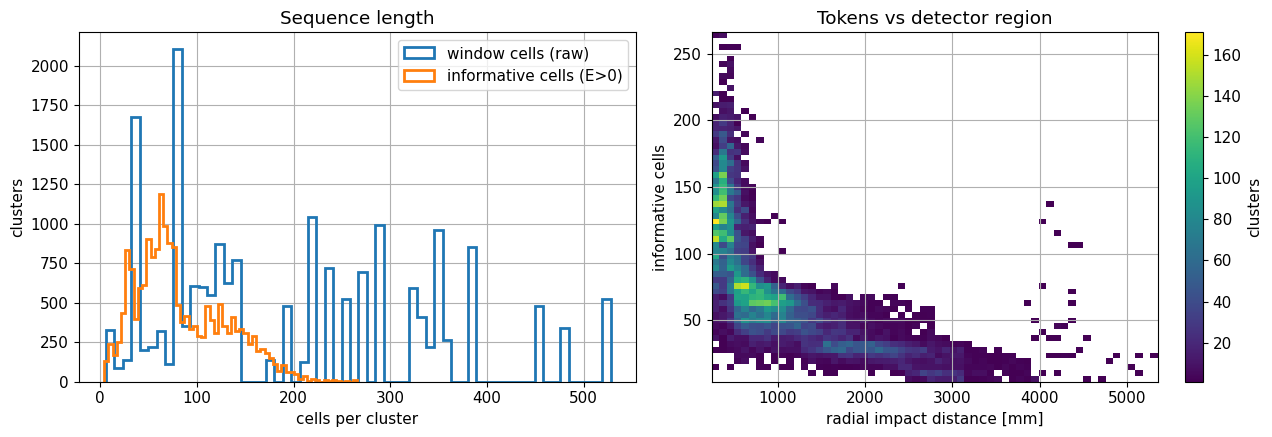

informative cells per cluster: p50=71  p95=169  p99=199  max=266
window cells              max=528


In [11]:
mask = valid_cell_mask(deep)
n_window = ak.to_numpy(ak.num(deep.energy, axis=1))
n_tokens = ak.to_numpy(ak.sum(mask, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(n_window, bins=60, histtype="step", lw=2, label="window cells (raw)")
axes[0].hist(n_tokens, bins=60, histtype="step", lw=2, label="informative cells (E>0)")
axes[0].set(xlabel="cells per cluster", ylabel="clusters", title="Sequence length")
axes[0].legend()

r_deep = np.hypot(ak.to_numpy(deep.sig_flux_entry_x), ak.to_numpy(deep.sig_flux_entry_y))
h = axes[1].hist2d(r_deep, n_tokens, bins=[60, 60], cmin=1)
plt.colorbar(h[3], ax=axes[1], label="clusters")
axes[1].set(xlabel="radial impact distance [mm]", ylabel="informative cells",
            title="Tokens vs detector region")
plt.tight_layout(); plt.show()

pct = np.percentile(n_tokens, [50, 95, 99, 100])
print("informative cells per cluster: p50=%d  p95=%d  p99=%d  max=%d" % tuple(pct))
print("window cells              max=%d" % n_window.max())

The window size depends strongly on the detector region: up to ~530 cells near the centre, tens
in the outer regions. The discrete bands in the right plot correspond to the module
technologies. Padding to the p99 length (about 200 tokens) covers almost everything, with a
maximum of 528. Even a plain O(N²) transformer is fine at this length; a linear-attention model
is comfortable.

### 5b. A granularity label derived from cell spacing

This production lacks `cell_modType` and `cell_pitch`, but the local cell size is implicit in
the cell coordinates. I define the local pitch of a cluster as the smallest positive spacing
between distinct `cell_x` values in its window. If this works, painting the ECAL face with it
should reproduce the module-region layout from the detector specification.

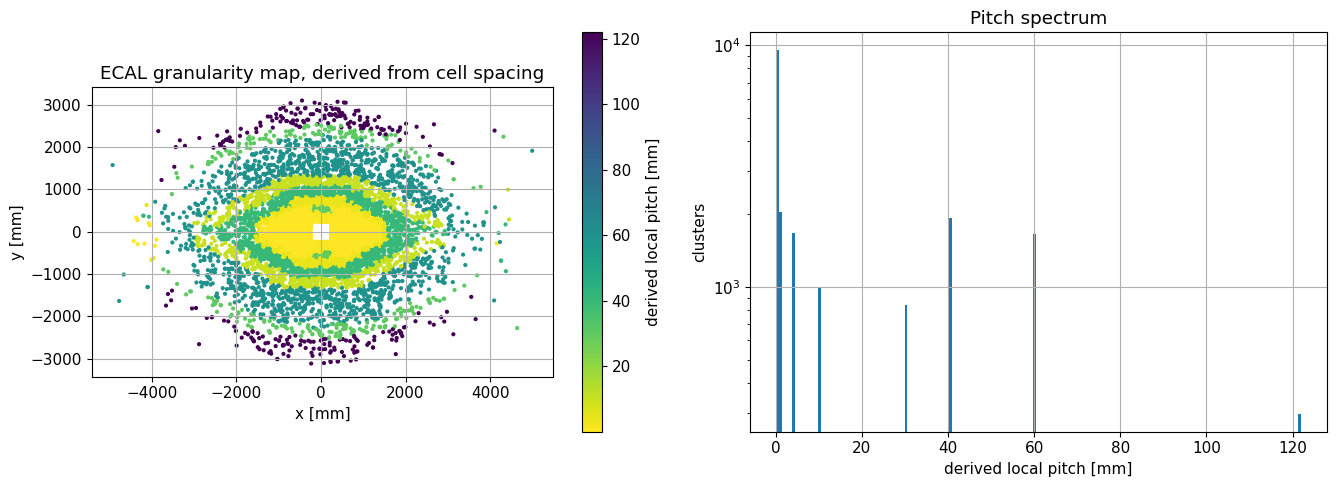

pitch classes (rounded to mm) and their token statistics:
  pitch ≈     0 mm:   9497 clusters,  tokens p50= 103  p99= 212
  pitch ≈     1 mm:   2042 clusters,  tokens p50= 110  p99= 171
  pitch ≈     4 mm:   1672 clusters,  tokens p50=  63  p99=  82
  pitch ≈    10 mm:   1000 clusters,  tokens p50=  41  p99=  67
  pitch ≈    30 mm:    842 clusters,  tokens p50=  58  p99=  93
  pitch ≈    40 mm:   1928 clusters,  tokens p50=  58  p99=  77
  pitch ≈    60 mm:   1647 clusters,  tokens p50=  28  p99=  35
  pitch ≈   122 mm:    299 clusters,  tokens p50=   9  p99=   9


In [12]:
cx_all = deep.cell_x
pitch = np.full(len(deep), np.nan)
for i in range(len(deep)):
    ux = np.unique(np.asarray(cx_all[i]))
    if len(ux) > 1:
        dx = np.diff(ux)
        dx = dx[dx > 0.1]
        if len(dx):
            pitch[i] = dx.min()

ex = ak.to_numpy(deep.sig_flux_entry_x); ey = ak.to_numpy(deep.sig_flux_entry_y)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
sc = axes[0].scatter(ex, ey, c=pitch, s=4, cmap="viridis_r",
                     vmin=np.nanpercentile(pitch, 1), vmax=np.nanpercentile(pitch, 99))
plt.colorbar(sc, ax=axes[0], label="derived local pitch [mm]")
axes[0].set(xlabel="x [mm]", ylabel="y [mm]", aspect="equal",
            title="ECAL granularity map, derived from cell spacing")

axes[1].hist(pitch[np.isfinite(pitch)], bins=200)
axes[1].set(xlabel="derived local pitch [mm]", ylabel="clusters", yscale="log",
            title="Pitch spectrum")
plt.tight_layout(); plt.show()

print("pitch classes (rounded to mm) and their token statistics:")
n_tok = ak.to_numpy(ak.sum(valid_cell_mask(deep), axis=1))
pr = np.round(pitch)
for p in sorted(np.unique(pr[np.isfinite(pr)])):
    m = pr == p
    if m.sum() > 50:
        print(f"  pitch ≈ {p:5.0f} mm: {m.sum():6d} clusters,  tokens p50={np.median(n_tok[m]):4.0f}  p99={np.percentile(n_tok[m],99):4.0f}")

The map reproduces the concentric module-technology regions of the Run5 ECAL specification
(compare Fig. 1 of the dataset description): fine pitch in the centre, coarse at the periphery.
The pitch spectrum is discrete, with one peak per module technology, so this derived quantity
can replace the missing `cell_modType`.

One artifact: the large "pitch ≈ 0–1 mm" class comes from module-boundary clusters. When a
window spans two technologies, the smallest spacing between distinct `cell_x` values measures
the offset between the two grids rather than a real cell size. These windows are also the
hardest case for any grid-based method, so a label that tags them is useful. In Week 2 the
loader should use the per-cell mode of the spacing instead of the minimum, plus a boundary flag.

## 6. Cell-level features

What are the dynamic ranges of the per-token features? This decides the normalisation.

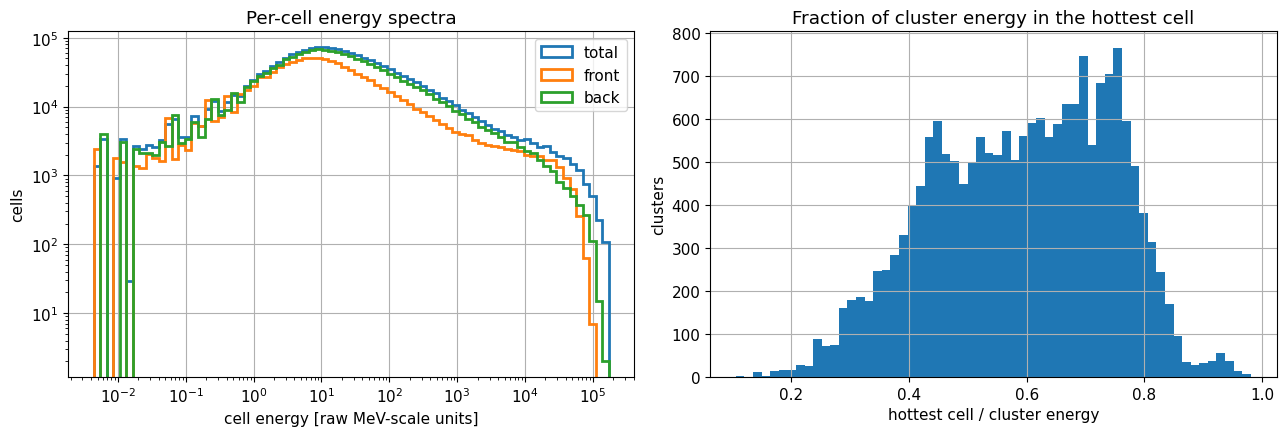

cell energy spans 4.4e-03 .. 1.7e+05 (7.6 decades) -> log-scale features
median hottest-cell fraction: 0.60


In [13]:
tokens = cluster_to_tokens(deep)
e_cells = ak.to_numpy(ak.flatten(tokens["e"]))
ef = ak.to_numpy(ak.flatten(tokens["e_front"]))
eb = ak.to_numpy(ak.flatten(tokens["e_back"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.geomspace(e_cells[e_cells > 0].min(), e_cells.max(), 80)
axes[0].hist(e_cells, bins=bins, histtype="step", lw=2, label="total")
axes[0].hist(ef[ef > 0], bins=bins, histtype="step", lw=2, label="front")
axes[0].hist(eb[eb > 0], bins=bins, histtype="step", lw=2, label="back")
axes[0].set(xscale="log", yscale="log", xlabel="cell energy [raw MeV-scale units]",
            ylabel="cells", title="Per-cell energy spectra")
axes[0].legend()

frac_seed = ak.to_numpy(ak.max(tokens["e"], axis=1) / ak.sum(tokens["e"], axis=1))
axes[1].hist(frac_seed, bins=60)
axes[1].set(xlabel="hottest cell / cluster energy", ylabel="clusters",
            title="Fraction of cluster energy in the hottest cell")
plt.tight_layout(); plt.show()
print("cell energy spans %.1e .. %.1e (%.1f decades) -> log-scale features"
      % (e_cells[e_cells>0].min(), e_cells.max(), np.log10(e_cells.max()/e_cells[e_cells>0].min())))
print("median hottest-cell fraction: %.2f" % np.median(frac_seed))

Cell energies span about 7 decades, so energy features need a log transform. The hottest cell
typically holds 30–60% of the cluster energy, as expected from the Molière radius: a few
dominant cells plus a long tail.

## 7. Longitudinal energy sharing

Shower maximum moves deeper with energy ($t_{\max} \propto \ln E$), so the front/back energy
split should correlate with true energy. I checked this on toy data for the proposal; here it
is on the real simulation.

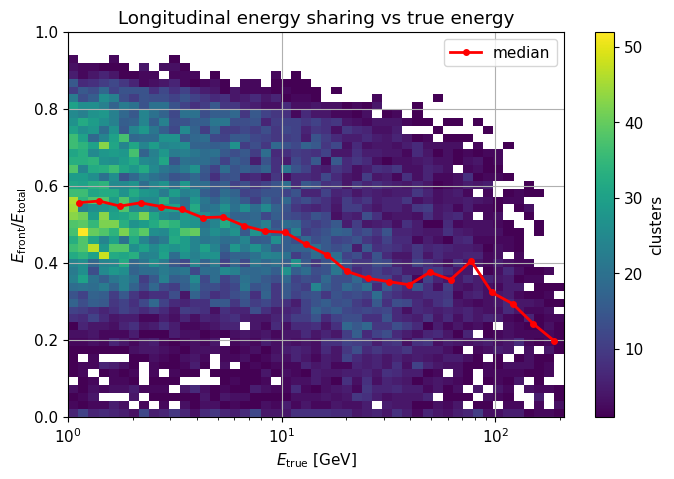

In [14]:
e_true_gev_deep = ak.to_numpy(deep.sig_flux_eTot)
f_front = ak.to_numpy(deep.total_energy_front / deep.total_energy)

fig, ax = plt.subplots(figsize=(8, 5))
h = ax.hist2d(e_true_gev_deep, f_front, bins=[np.geomspace(1, 210, 50), np.linspace(0, 1, 50)],
              cmin=1)
plt.colorbar(h[3], label="clusters")
# profile: median fraction per energy bin
ebins = np.geomspace(1, 210, 25)
ctr, prof = [], []
for lo, hi in zip(ebins[:-1], ebins[1:]):
    sel = (e_true_gev_deep >= lo) & (e_true_gev_deep < hi)
    if sel.sum() > 20:
        ctr.append(np.sqrt(lo * hi)); prof.append(np.median(f_front[sel]))
ax.plot(ctr, prof, "r-o", ms=4, lw=2, label="median")
ax.set(xscale="log", xlabel=r"$E_{\rm true}$ [GeV]", ylabel=r"$E_{\rm front}/E_{\rm total}$",
       title="Longitudinal energy sharing vs true energy")
ax.legend()
plt.show()

The front-energy fraction falls steadily with energy, with a large spread at fixed energy. That
spread is per-shower depth information that no 2D model has access to. Section 8d quantifies
how much of it is recoverable.

## 8. Baseline energy response

How well does a calibrated sum of cells reconstruct the photon energy? I first tried the
simplest possible calibration (8a), found that it fails badly, traced the reason (8b), and then
measured the baseline where its assumptions actually hold (8c).

Conventions: median bias and robust σ (half-width of the central 68% interval) because the
tails are non-Gaussian; splits keyed on the event index so photons from the same event never
straddle train/test; matching cut `sig_dr_matched < 100 mm` (section 9).

### 8a. Single-constant calibration

Calibrate with one factor, `k = median(E_true / total_energy)`, fitted on the training split,
as one would for a linear calorimeter.

matching-quality cut keeps 93.5% of clusters


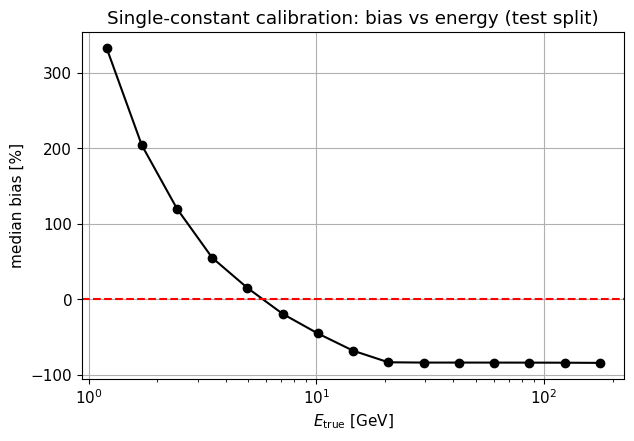

bias: +333% at ~1 GeV ... -84% at ~200 GeV


In [15]:
qcut = df.sig_dr_matched < 100.0
print("matching-quality cut keeps %.1f%% of clusters" % (100 * qcut.mean()))
d = df[qcut].copy()
is_train = (d.event % 2 == 0)   # whole events land on one side (siblings share the index)

def robust_sigma(x):
    q16, q84 = np.percentile(x, [15.865, 84.135])
    return 0.5 * (q84 - q16)

k_naive = np.median(d.e_true_gev[is_train] / d.total_energy[is_train])
resp_naive = (k_naive * d.total_energy - d.e_true_gev) / d.e_true_gev

ebins = np.geomspace(1, 210, 16)
def binned(e, resp, stat):
    out_c, out_v = [], []
    for lo, hi in zip(ebins[:-1], ebins[1:]):
        sel = (e >= lo) & (e < hi)
        if sel.sum() >= 50:
            out_c.append(np.sqrt(lo * hi)); out_v.append(stat(resp[sel]))
    return np.array(out_c), np.array(out_v)

c, bias_n = binned(d.e_true_gev[~is_train], resp_naive[~is_train], np.median)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(c, 100 * bias_n, "ko-")
ax.axhline(0, color="r", ls="--")
ax.set(xscale="log", xlabel=r"$E_{\rm true}$ [GeV]", ylabel="median bias [%]",
       title="Single-constant calibration: bias vs energy (test split)")
plt.show()
print("bias: %+.0f%% at ~1 GeV ... %+.0f%% at ~200 GeV" % (100*bias_n[0], 100*bias_n[-1]))

The bias swings from about +300% at 1 GeV to −84% at 200 GeV, so `total_energy` is not
proportional to the photon energy and no global constant can fix it. Something ends up in the
window that does not belong to the matched photon.

### 8b. Diagnosis: clusters are shared between photons

Two checks: do several truth photons in the same event point to the same reconstructed cluster,
and does the response depend on the distance to the nearest sibling photon?

In [16]:
# 1. cluster sharing: same (file, event, x_cluster, y_cluster) for several photons
key = (df.file.astype(str) + "_" + df.event.astype(str) + "_"
       + df.x_cluster.round(2).astype(str) + "_" + df.y_cluster.round(2).astype(str))
shared = key.duplicated(keep=False)
print("photons whose matched cluster is ALSO matched to another photon: %.1f%%"
      % (100 * shared.mean()))

# 2. isolation: distance to the nearest sibling photon in the same event
df["iso"] = np.inf
for (_, _), g in df.groupby(["file", "event"]):
    if len(g) > 1:
        xy = g[["sig_flux_entry_x", "sig_flux_entry_y"]].values
        dist = np.sqrt(((xy[:, None, :] - xy[None, :, :]) ** 2).sum(-1))
        np.fill_diagonal(dist, np.inf)
        df.loc[g.index, "iso"] = dist.min(1)

ratio = df.total_energy / df.e_true_gev
ok = df.sig_dr_matched < 100
print("\nmedian(total_energy / E_true)  per E bin [1-4, 4-16, 16-64, 64-250] GeV:")
for label, sel in [("all (dr<100mm)", ok),
                   ("isolated  (no sibling within 200mm)", ok & (df.iso > 200)),
                   ("non-isolated (sibling within 100mm)", ok & (df.iso < 100))]:
    row = []
    for lo, hi in [(1, 4), (4, 16), (16, 64), (64, 250)]:
        s = sel & (df.e_true_gev >= lo) & (df.e_true_gev < hi)
        row.append("%8.0f" % np.median(ratio[s]) if s.sum() > 30 else "    -   ")
    print(f"  {label:38s} n={sel.sum():6d}   " + " ".join(row))

photons whose matched cluster is ALSO matched to another photon: 66.7%



median(total_energy / E_true)  per E bin [1-4, 4-16, 16-64, 64-250] GeV:
  all (dr<100mm)                         n=186617      16261     4424      988      974
  isolated  (no sibling within 200mm)    n= 60698       3630      978      961      971
  non-isolated (sibling within 100mm)    n=123907      21016     6786     2764     1550


About 67% of entries share their reconstructed cluster with at least one sibling photon, and
this explains the response:

- Isolated photons (nearest sibling > 200 mm): the response is flat at about 960–980 raw units
  per GeV above ~4 GeV. The detector is linear after all.
- Non-isolated photons: the window sums energy from overlapping sibling showers. A low-energy
  photon next to a high-energy sibling inherits its energy, which inflates the response by up
  to ×20 at 1 GeV.
- Isolated photons still show an excess at 1–4 GeV (about ×3.7), which points to a diffuse
  energy floor in the window. This goes on the mentor-question list.

So energy regression on this dataset cannot be separated from overlap handling. A sum of cells
cannot tell which energy belongs to which photon; a model that sees the spatial and temporal
pattern of the cells at least has a chance.

### 8c. Baseline on isolated photons

I quote the baseline where its assumptions hold: isolated photons (`iso > 200 mm`), well
matched (`dr < 100 mm`). The resolution is fitted as $\sigma(E)/E = a/\sqrt{E} \oplus b$ in the
region where contamination is negligible (E > 10 GeV). The contaminated regimes are quoted
separately.

gain calibration on isolated train photons (E>4 GeV): k = 1.0346e-03 GeV/raw (1/k = 967)


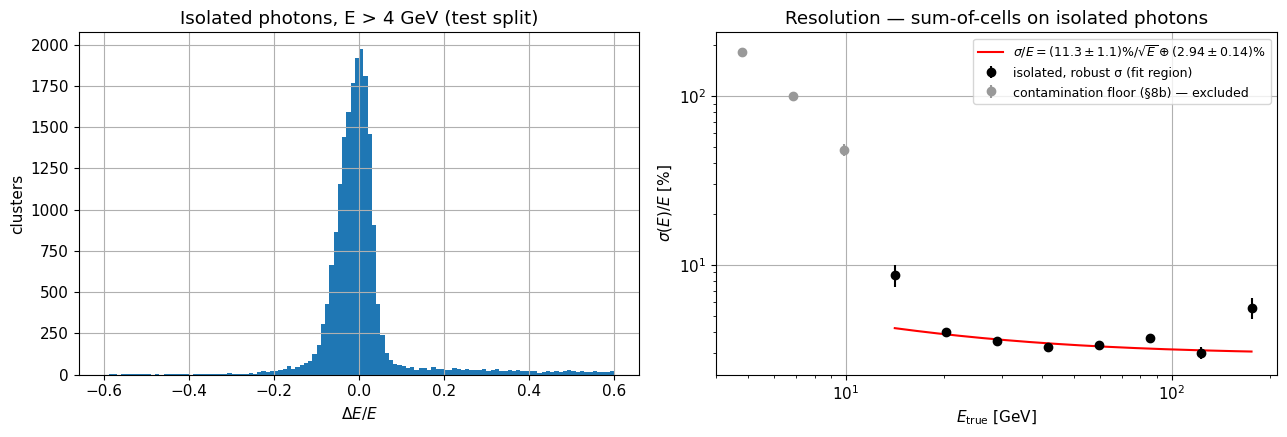


BASELINE (isolated, test split): a = 11.3 ± 1.1 %/sqrt(E),  b = 2.94 ± 0.14 %
global E>4 GeV: median bias -0.001, robust σ 0.095, p68 0.054, n=21920
  E≈   4.8 GeV  σ=(181.52±11.35)%  bias=+41.96%   [excluded from fit]
  E≈   6.9 GeV  σ=( 99.78±5.64)%  bias= +4.58%   [excluded from fit]
  E≈   9.8 GeV  σ=( 47.82±3.88)%  bias= -0.16%   [excluded from fit]
  E≈  14.1 GeV  σ=(  8.64±1.29)%  bias= -1.53%
  E≈  20.2 GeV  σ=(  4.01±0.09)%  bias= -1.47%
  E≈  29.0 GeV  σ=(  3.53±0.06)%  bias= -0.93%
  E≈  41.5 GeV  σ=(  3.27±0.09)%  bias= +0.02%
  E≈  59.6 GeV  σ=(  3.33±0.19)%  bias= +0.57%
  E≈  85.4 GeV  σ=(  3.70±0.18)%  bias= +0.77%
  E≈ 122.4 GeV  σ=(  3.01±0.25)%  bias= +0.40%
  E≈ 175.4 GeV  σ=(  5.58±0.80)%  bias= -0.82%
CHALLENGE non-isolated (<100mm), E>4   median bias   +4.41, p68    7.61, n=25608
CHALLENGE all photons, E<4             median bias  +15.96, p68   28.59, n=45491


In [17]:
sel_base = (df.sig_dr_matched < 100) & (df.iso > 200)
b_ = df[sel_base].copy()
tr = (b_.event % 2 == 0)
k_gain = np.median(b_.e_true_gev[tr & (b_.e_true_gev > 4)]
                   / b_.total_energy[tr & (b_.e_true_gev > 4)])
print("gain calibration on isolated train photons (E>4 GeV): k = %.4e GeV/raw (1/k = %.0f)"
      % (k_gain, 1 / k_gain))

b_["resp"] = (k_gain * b_.total_energy - b_.e_true_gev) / b_.e_true_gev
test = b_[~tr]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
hi_e = test.e_true_gev > 4
axes[0].hist(test.resp[hi_e], bins=120, range=(-0.6, 0.6))
axes[0].set(xlabel=r"$\Delta E / E$", ylabel="clusters",
            title="Isolated photons, E > 4 GeV (test split)")

# per-bin robust sigma with bootstrap uncertainties
rng_boot = np.random.default_rng(1)
rbins = np.geomspace(4, 210, 12)
c_res, sig_res, sig_err, bias_res = [], [], [], []
for lo, hi in zip(rbins[:-1], rbins[1:]):
    x = test.resp[(test.e_true_gev >= lo) & (test.e_true_gev < hi)].values
    if len(x) >= 80:
        c_res.append(np.sqrt(lo * hi))
        sig_res.append(robust_sigma(x))
        sig_err.append(np.std([robust_sigma(rng_boot.choice(x, len(x))) for _ in range(200)]))
        bias_res.append(np.median(x))
c_res, sig_res, sig_err = map(np.array, (c_res, sig_res, sig_err))

# fit a/sqrt(E) (+) b, weighted, only where the calibrated-sum assumptions hold (E > 10 GeV);
# below that the diffuse contamination floor of section 8b dominates and the model is wrong.
from scipy.optimize import curve_fit
model = lambda E, a, b: np.sqrt(a**2 / E + b**2)
fit_sel = c_res > 10
(a_f, b_f), cov = curve_fit(model, c_res[fit_sel], sig_res[fit_sel],
                            sigma=sig_err[fit_sel], absolute_sigma=True, p0=[0.3, 0.03])
a_e, b_e = np.sqrt(np.diag(cov))
axes[1].errorbar(c_res[fit_sel], 100 * sig_res[fit_sel], yerr=100 * sig_err[fit_sel],
                 fmt="ko", label="isolated, robust σ (fit region)")
axes[1].errorbar(c_res[~fit_sel], 100 * sig_res[~fit_sel], yerr=100 * sig_err[~fit_sel],
                 fmt="o", color="0.6", label="contamination floor (§8b) — excluded")
ee = np.geomspace(c_res[fit_sel][0], c_res[-1], 200)
axes[1].plot(ee, 100 * model(ee, a_f, b_f), "r-",
             label=(rf"$\sigma/E = ({100*abs(a_f):.1f}\pm{100*a_e:.1f})\%/\sqrt{{E}}"
                    rf" \oplus ({100*abs(b_f):.2f}\pm{100*b_e:.2f})\%$"))
axes[1].set(xscale="log", yscale="log", xlabel=r"$E_{\rm true}$ [GeV]",
            ylabel=r"$\sigma(E)/E$ [%]",
            title="Resolution — sum-of-cells on isolated photons")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print("\nBASELINE (isolated, test split): a = %.1f ± %.1f %%/sqrt(E),  b = %.2f ± %.2f %%"
      % (100*abs(a_f), 100*a_e, 100*abs(b_f), 100*b_e))
print("global E>4 GeV: median bias %+.3f, robust σ %.3f, p68 %.3f, n=%d"
      % (np.median(test.resp[hi_e]), robust_sigma(test.resp[hi_e]),
         np.percentile(abs(test.resp[hi_e]), 68), hi_e.sum()))
for cc, ss, se, bb in zip(c_res, sig_res, sig_err, bias_res):
    tag = "" if cc > 10 else "   [excluded from fit]"
    print(f"  E≈{cc:6.1f} GeV  σ=({100*ss:6.2f}±{100*se:.2f})%  bias={100*bb:+6.2f}%{tag}")

# challenge numbers: where the classical method breaks
chal = df[(df.sig_dr_matched < 100) & (df.event % 2 == 1)].copy()
chal["resp"] = (k_gain * chal.total_energy - chal.e_true_gev) / chal.e_true_gev
for label, sel in [("non-isolated (<100mm), E>4", (chal.iso < 100) & (chal.e_true_gev > 4)),
                   ("all photons, E<4", chal.e_true_gev < 4)]:
    print("CHALLENGE %-28s median bias %+7.2f, p68 %7.2f, n=%d"
          % (label, np.median(chal.resp[sel]), np.percentile(abs(chal.resp[sel]), 68), sel.sum()))

These are the Week-1 reference numbers:

1. On isolated showers the calibrated sum behaves like a textbook calorimeter:
   $\sigma/E = (11.3\pm1.1)\%/\sqrt{E} \oplus (2.94\pm0.14)\%$. The constant term b ≈ 2.9% is
   what the proposal aims to reduce using depth and timing.
2. The grey points below 10 GeV are the contamination floor from 8b, not a noise term, so I
   exclude them from the fit instead of absorbing them into a c/E term.
3. The challenge rows (non-isolated, low energy) are where a model has the most room to
   improve, through overlap separation.

### 8d. How much information does the depth carry?

Section 7 showed that the front/back split correlates with energy. The sharper question: at
fixed true energy, do the baseline's residuals correlate with the depth proxy
$f = E_{\rm front}/E_{\rm total}$? If they do, that correlation is resolution a depth-aware
model could recover. I bin in true energy here, which a deployed estimator cannot do, so this
measures information content rather than defining an algorithm.

Since rear leakage grows with energy, the correlation should appear at high energy.

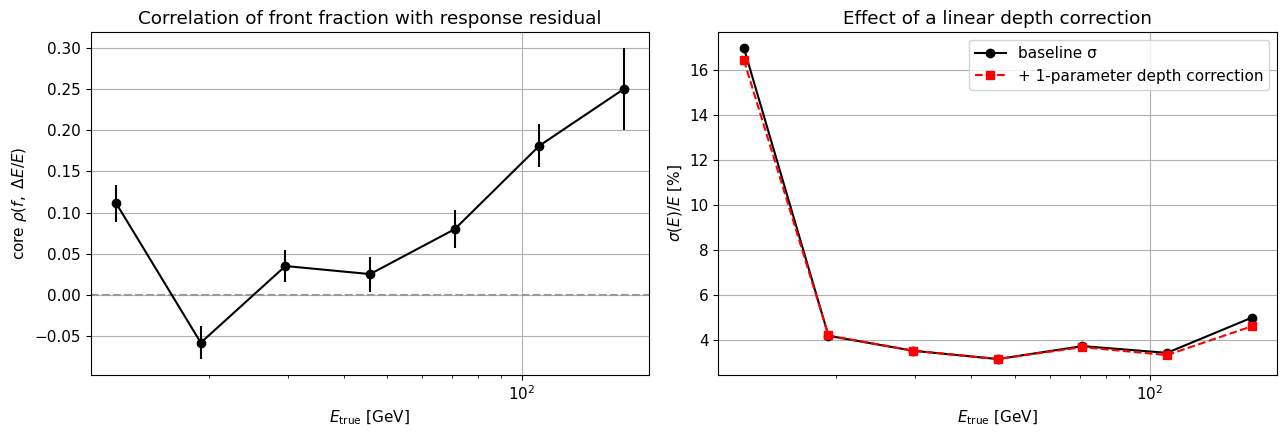

  E≈  12.4 GeV  rho = +0.111 ± 0.022   σ 17.00% → 16.46%  (+3%)  n=2820
  E≈  19.2 GeV  rho = -0.058 ± 0.020   σ  4.18% →  4.20%  (-0%)  n=3720
  E≈  29.7 GeV  rho = +0.035 ± 0.020   σ  3.52% →  3.52%  (-0%)  n=3470
  E≈  45.8 GeV  rho = +0.025 ± 0.021   σ  3.15% →  3.15%  (-0%)  n=2752
  E≈  70.8 GeV  rho = +0.080 ± 0.023   σ  3.73% →  3.68%  (+1%)  n=2038
  E≈ 109.4 GeV  rho = +0.181 ± 0.026   σ  3.43% →  3.33%  (+3%)  n=1423
  E≈ 169.0 GeV  rho = +0.250 ± 0.050   σ  4.99% →  4.61%  (+8%)  n=662


In [18]:
b_["f"] = b_.total_energy_front / b_.total_energy
abins = np.geomspace(10, 210, 8)
rng_a = np.random.default_rng(2)
rows = []
for lo, hi in zip(abins[:-1], abins[1:]):
    g = b_[(b_.sig_flux_eTot >= lo) & (b_.sig_flux_eTot < hi)]
    gtr, gte = g[g.event % 2 == 0], g[g.event % 2 == 1]
    if len(gte) < 300:
        continue
    # robust core (3 robust-sigma around the median) — LS on the tails is meaningless
    med, s0 = np.median(gtr.resp), robust_sigma(gtr.resp)
    core_tr = gtr[abs(gtr.resp - med) < 3 * s0]
    slope = np.polyfit(core_tr.f, core_tr.resp, 1)
    corrected = gte.resp.values - np.polyval(slope, gte.f.values)
    mte, ste = np.median(gte.resp), robust_sigma(gte.resp)
    core_te = gte[abs(gte.resp - mte) < 3 * ste]
    rho = np.corrcoef(core_te.f, core_te.resp)[0, 1]
    rho_b = np.std([np.corrcoef(*core_te.sample(frac=1, replace=True)[["f", "resp"]].values.T)[0, 1]
                    for _ in range(200)])
    rows.append(dict(e=np.sqrt(lo * hi), rho=rho, rho_err=rho_b,
                     s_raw=robust_sigma(gte.resp.values), s_cor=robust_sigma(corrected),
                     n=len(gte)))
aud = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].errorbar(aud.e, aud.rho, yerr=aud.rho_err, fmt="ko-")
axes[0].axhline(0, color="0.6", ls="--")
axes[0].set(xscale="log", xlabel=r"$E_{\rm true}$ [GeV]",
            ylabel=r"core $\rho(f,\ \Delta E/E)$",
            title="Correlation of front fraction with response residual")
axes[1].plot(aud.e, 100 * aud.s_raw, "ko-", label="baseline σ")
axes[1].plot(aud.e, 100 * aud.s_cor, "rs--", label="+ 1-parameter depth correction")
axes[1].set(xscale="log", xlabel=r"$E_{\rm true}$ [GeV]", ylabel=r"$\sigma(E)/E$ [%]",
            title="Effect of a linear depth correction")
axes[1].legend()
plt.tight_layout(); plt.show()

for r in rows:
    gain = 100 * (1 - r["s_cor"] / r["s_raw"])
    print(f"  E≈{r['e']:6.1f} GeV  rho = {r['rho']:+.3f} ± {r['rho_err']:.3f}   "
          f"σ {100*r['s_raw']:5.2f}% → {100*r['s_cor']:5.2f}%  ({gain:+.0f}%)  n={r['n']}")

The correlation is consistent with zero below ~50 GeV and rises to ρ = +0.18 ± 0.03 at 110 GeV
and +0.25 ± 0.05 at 170 GeV, where showers penetrate deep enough to leak out the back. A single
linear depth parameter already recovers 3–8% of the resolution there; the full per-cell depth
pattern, and the timing from 4b, should contain more.

Caveats: (1) I binned in true energy, so a real estimator has to learn this energy dependence
jointly. (2) I also tried a global polynomial correction and it makes the resolution worse —
the contamination tails dominate any unbinned least-squares fit — so the information is
conditional and non-linear. (3) Most LHCb photons are at low energy, where the gain has to
come from contamination rejection (8b) rather than leakage correction; the two are
complementary.

## 9. Position

How far is the reconstructed cluster position from the true entry point? This justifies the
`dr < 100 mm` cut used in section 8 and looks at position reconstruction as a task.

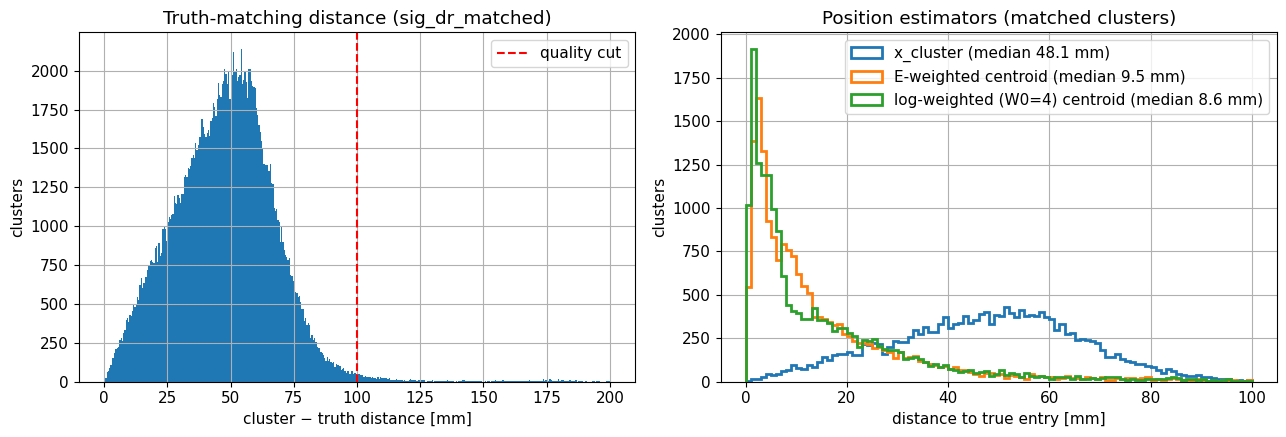

sig_dr_matched: median 49.6 mm, p95 413.5 mm, frac > 100 mm: 6.48%


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df.sig_dr_matched, bins=400, range=(0, 200))
axes[0].axvline(100, color="r", ls="--", label="quality cut")
axes[0].set(xlabel="cluster − truth distance [mm]", ylabel="clusters",
            title="Truth-matching distance (sig_dr_matched)")
axes[0].legend()

# energy-weighted and log-weighted (W0) centroids as position estimators (deep sample)
mask = valid_cell_mask(deep)
w = deep.energy[mask]
cx = ak.to_numpy(ak.sum(deep.cell_x[mask] * w, axis=1) / ak.sum(w, axis=1))
cy = ak.to_numpy(ak.sum(deep.cell_y[mask] * w, axis=1) / ak.sum(w, axis=1))
# standard calorimetry log-weighting: w_i = max(0, W0 + ln(E_i / E_tot)), W0 = 4
W0 = 4.0
frac = w / ak.sum(w, axis=1)
wl = np.maximum(W0 + np.log(frac), 0)
lx = ak.to_numpy(ak.sum(deep.cell_x[mask] * wl, axis=1) / ak.sum(wl, axis=1))
ly = ak.to_numpy(ak.sum(deep.cell_y[mask] * wl, axis=1) / ak.sum(wl, axis=1))
tx = ak.to_numpy(deep.sig_flux_entry_x); ty = ak.to_numpy(deep.sig_flux_entry_y)
dr_centroid = np.hypot(cx - tx, cy - ty)
dr_logw = np.hypot(lx - tx, ly - ty)
dr_cluster = ak.to_numpy(deep.sig_dr_matched)
ok = dr_cluster < 100
axes[1].hist(dr_cluster[ok], bins=100, range=(0, 100), histtype="step", lw=2,
             label=f"x_cluster (median {np.median(dr_cluster[ok]):.1f} mm)")
axes[1].hist(dr_centroid[ok], bins=100, range=(0, 100), histtype="step", lw=2,
             label=f"E-weighted centroid (median {np.median(dr_centroid[ok]):.1f} mm)")
axes[1].hist(dr_logw[ok], bins=100, range=(0, 100), histtype="step", lw=2,
             label=f"log-weighted (W0=4) centroid (median {np.median(dr_logw[ok]):.1f} mm)")
axes[1].set(xlabel="distance to true entry [mm]", ylabel="clusters",
            title="Position estimators (matched clusters)")
axes[1].legend()
plt.tight_layout(); plt.show()
print("sig_dr_matched: median %.1f mm, p95 %.1f mm, frac > 100 mm: %.2f%%"
      % (np.median(df.sig_dr_matched), np.percentile(df.sig_dr_matched, 95),
         100 * (df.sig_dr_matched > 100).mean()))

The matching distance has a core below ~80 mm (roughly the module scale) and a sparse tail out
to metres. The tail entries are probably mismatches from the multi-photon events, and the
100 mm cut removes them.

The stored cluster position turns out to be coarse. `x_cluster` takes only ~140 distinct
values per file (it is not the max-energy cell, which matches it in only ~12% of clusters) and
sits a median 48 mm from the true entry point. A plain energy-weighted centroid of the window
cells gets 9.5 mm, and the standard log-weighting
($w_i = \max(0,\, W_0 + \ln(E_i/E_{\rm tot}))$, $W_0=4$) gets 8.6 mm. So `sig_dr_matched`, and
the matching itself, is dominated by this quantization rather than by physical shower
displacement, and the log-weighted centroid is the right classical baseline for position. What
`x_cluster` represents exactly is mentor question 6.

## 10. Event displays

Three example clusters at different energies and detector regions. Marker size is cell energy
(log scale); colour is the cleaned front time.

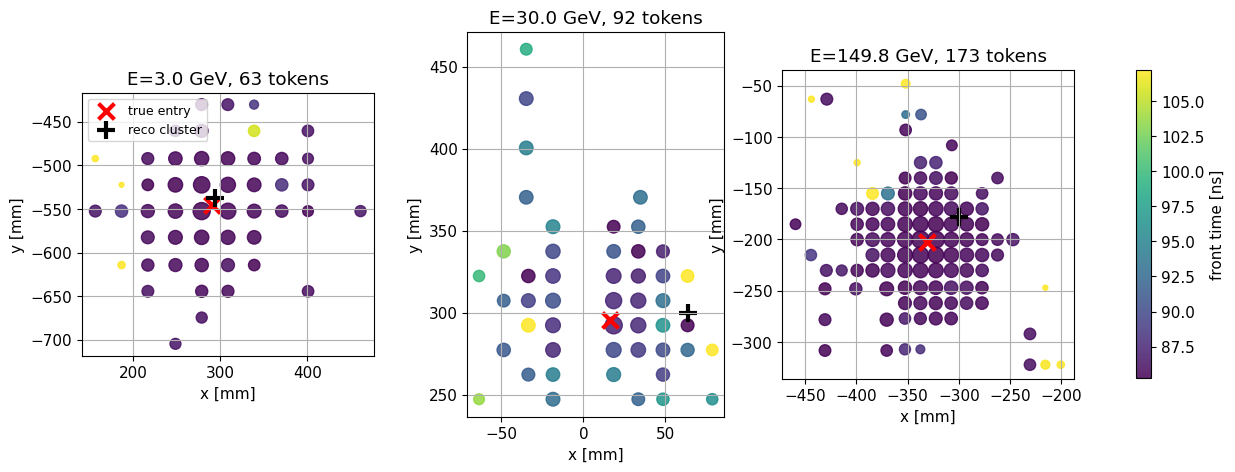

In [20]:
def show_cluster(ax, i):
    m = ak.to_numpy(valid_cell_mask(deep)[i])
    x = ak.to_numpy(deep.cell_x[i])[m]; y = ak.to_numpy(deep.cell_y[i])[m]
    e = ak.to_numpy(deep.energy[i])[m]
    t = ak.to_numpy(clean_cell_times(deep.cell_times_front, valid_cell_mask(deep))[i])[m]
    s = 12 + 140 * (np.log10(e) - np.log10(e.min())) / max(np.log10(e.max()/e.min()), 1e-9)
    # clip the colour range to the bulk of the cleaned times, else one outlier
    # paints every other cell the same colour
    finite_t = t[np.isfinite(t)]
    vmin, vmax = (np.percentile(finite_t, [5, 95]) if len(finite_t) > 3 else (None, None))
    sc = ax.scatter(x, y, s=s, c=t, alpha=0.85, vmin=vmin, vmax=vmax)
    ax.scatter(deep.sig_flux_entry_x[i], deep.sig_flux_entry_y[i],
               marker="x", s=130, lw=3, color="red", label="true entry")
    ax.scatter(deep.x_cluster[i], deep.y_cluster[i],
               marker="+", s=160, lw=3, color="k", label="reco cluster")
    ax.set(title=f"E={deep.sig_flux_eTot[i]:.1f} GeV, {m.sum()} tokens",
           xlabel="x [mm]", ylabel="y [mm]", aspect="equal")
    return sc

e_all = ak.to_numpy(deep.sig_flux_eTot)
dr_all = ak.to_numpy(deep.sig_dr_matched)
picks = [int(np.argmin(abs(e_all - target) + 1e6 * (dr_all > 50))) for target in (3, 30, 150)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, i in zip(axes, picks):
    sc = show_cluster(ax, i)
axes[0].legend(loc="upper left", fontsize=9)
fig.colorbar(sc, ax=axes, label="front time [ns]", shrink=0.8)
plt.show()

Each display is one model input: a variable-length set of (x, y, E_front, E_back, t_front,
t_back) tokens. Visible here: the energy core around the true entry point, the
region-dependent cell sizes, and some time structure across the shower footprint.

## 11. Summary, decisions and questions for the mentors

### Findings and decisions

| # | Finding | Decision for the pipeline |
|---|---|---|
| 1 | `sig_flux_eTot` is in GeV, not MeV (spec says MeV; the mentor notebook converts) | Loader converts explicitly; units asserted in tests |
| 2 | `total_energy` is uncalibrated raw output | Baselines fit a calibration on the train split; never quote raw response |
| 3 | Arrays are jagged; `n*` equals the length; ~50% of window cells are silent | Tokens = cells with E > 0; no padding logic needed at load time |
| 4 | Timing has uninitialised values in silent cells; clean times centre at ~86 ns | `clean_cell_times` (energy mask + sanity window), unit-tested |
| 5 | Up to ~13 photons/event, sometimes ~1 mm apart | Split by `(file, event)`, never by entry |
| 6 | 67% of photons share their cluster with a sibling; isolated photons show a flat gain ≈ 970/GeV, non-isolated inherit sibling energy | Report isolated/non-isolated metrics separately; loader gets an isolation flag |
| 7 | `sig_flux_timing` is the truth arrival time at the ECAL (checked against d/c) | Timing reference / possible auxiliary target |
| 8 | Cell-time resolution scales with cell energy: ~0.9 ns down to ~12 ps for the hottest cells (SPIDER design 15 ps) | Smearing looks realistic, so the timing ablation is meaningful |
| 9 | Sequences: p50 ≈ 70, p99 ≈ 200, max 528 informative cells | Pad-to-p99 batching; attention cost is no problem |
| 10 | Cell energies span ~7 decades | log-energy token features |
| 11 | Local pitch derived from cell spacing reproduces the Run5 region layout | Replacement for the missing `cell_modType`; goes into the loader in Week 2 |
| 12 | Baseline (isolated): σ/E = (11.3±1.1)%/√E ⊕ (2.94±0.14)%; contaminated regimes quoted separately | Reference numbers for any model |
| 13 | Depth–residual correlation grows with energy: ρ ≈ 0 below 50 GeV, +0.25±0.05 at 170 GeV; a linear correction gains 3–8%, a global one fails | Measured headroom for a conditional model (8d) |
| 14 | `x_cluster` is quantized (~140 distinct values/file, median 48 mm from truth); a log-weighted centroid reaches 8.6 mm | Use the W0 centroid as the classical position baseline, not `x_cluster` |

### Questions for the mentors

1. Cluster sharing (the most important one): about 67% of matched photons point to a cluster
   that is also the best match of another photon, and their summed energy reflects both
   showers. Is this expected from the preprocessing (one cluster kept per photon, not per
   event)? For energy-regression training, should I (a) keep only isolated photons, (b) keep
   one photon per cluster, for example the highest-energy one, or (c) treat it as an
   overlap-separation task from the start?
2. Diffuse energy floor: even isolated low-energy photons show about ×3.7 response at
   1–4 GeV. Is there rest-of-event energy in the windows despite "no minbias", or a per-cell
   threshold or noise model I should know about?
3. Missing branches: `cell_pitch`, `cell_modType` and `cell_rel_*` are absent from this
   production. Will a future production include them, or should I keep deriving the
   granularity from the cell spacing (section 5b)?
4. Timing model: cell times sit about 43 ns after the photon's arrival, and their resolution
   scales with cell energy down to ~12 ps for the hottest cells (section 4b), which looks like
   a realistic SPIDER-like smearing. Can you confirm what smearing the simulation applies, so
   I can state it precisely in the timing ablation?
5. Conventions: `sig_flux_eTot` in GeV and reco energies in raw uncalibrated units (gain about
   970/GeV) — is that right? And is `sig_dr_matched < 100 mm` a standard quality cut?
6. Cluster position: `x_cluster`/`y_cluster` take ~140 distinct values per file and sit a
   median 48 mm from the true entry, while a simple log-weighted centroid reaches 8.6 mm
   (section 9). What does the stored position represent (seed module centre?), and is the
   truth matching done with it? If so, should I re-match using the centroid?

### Next steps (Week 2)

1. PyTorch `Dataset` + collate (pad-to-batch-max, mask) on top of `cluster_to_tokens`, with
   `(file, event)`-keyed splits and an isolation flag per cluster.
2. Formalise §8 as the evaluation module (`bias`, `p68`, robust σ, a/√E ⊕ b ⊕ c/E fit) with tests —
   always reported for {isolated, non-isolated} × {E<4, E>4} cells.
3. Cellular Automaton baseline port; first resolution table: CA vs Graph Clustering vs calibrated sum.
4. Promote the §5b pitch derivation into the loader (per-cell spacing mode + boundary flag) as
   the region label; adopt the W0 log-weighted centroid as the classical position baseline.
5. Mentor sync on the six questions above — answers to Q1/Q2/Q6 may reshape the training targets.